In [1]:
import pandas as pd
from pathlib import Path

In [16]:
caminho = "base_meses_2026"

In [ ]:
pasta = Path(caminho)
if not pasta.exists():
    raise FileNotFoundError(
        f"Caminho não encontrado: {pasta}"
    )
arq_meses = sorted(
    f for f in pasta.iterdir()
)
if not arq_meses:
    raise FileNotFoundError(
        f"Nenhum arquivo foi encontrado na pasta: {pasta}"
    )
print(f"{len(arq_meses)} arquivos encontrados")
    
df_meses_delivery = pd.DataFrame()
for arquivo_mes in arq_meses:
    df_mes = pd.read_csv(arquivo_mes)
    df_meses_delivery = pd.concat([df_mes, df_meses_delivery])
    
df_meses_delivery["Time"] = pd.to_datetime(df_meses_delivery["Time"])
df_meses_delivery = (
    df_meses_delivery.drop_duplicates(subset="Time", keep="last")
    .sort_values("Time")
    .reset_index(drop=True)
)


10 arquivos encontrados


In [25]:
df_meses_delivery.to_csv("food_delivery_sp_2026.csv", index=False)

In [20]:
df_meses_delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Time           281 non-null    datetime64[us]
 1   Food delivery  281 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 4.5 KB


In [23]:
df_meses_delivery.head()

,Time,Food delivery
0,2026-01-01,0
1,2026-01-02,82
2,2026-01-03,0
3,2026-01-04,0
4,2026-01-05,0


In [24]:
df_meses_delivery.tail()

,Time,Food delivery
276,2026-10-04,80
277,2026-10-05,87
278,2026-10-06,73
279,2026-10-07,98
280,2026-10-08,76


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = df_meses_delivery.rename(columns={"Time": "data", "Food delivery": "v"}).copy()
df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.to_period("M")
rotulos = [p.strftime("%b") for p in sorted(df["mes"].unique())]

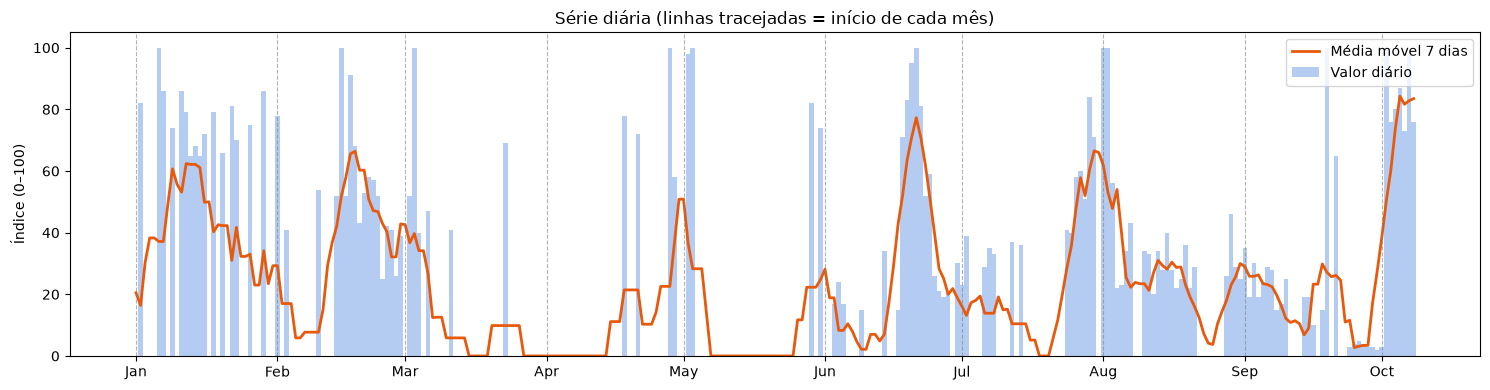

In [27]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(df["data"], df["v"], color="#2a6fdb", alpha=0.35, width=1, label="Valor diário")
ax.plot(df["data"], df["v"].rolling(7, center=True, min_periods=1).mean(),
        color="#e8590c", lw=2, label="Média móvel 7 dias")
for d in pd.date_range(df["data"].min(), df["data"].max(), freq="MS"):
    ax.axvline(d, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.set_title("Série diária (linhas tracejadas = início de cada mês)")
ax.set_ylabel("Índice (0–100)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()